# how the neural networks work
### A guide through both models (mostly for future me to understand)

---

**Spis treści:**
1. [Co to sieć neuronowa?](#idea)
2. [Architektura sieci](#architektura)
3. [Jak sieć się uczy? (Propagacja wsteczna)](#uczenie)
4. [Model Klasyfikacyjny — zdrowie psychiczne](#klasyfikacja)
5. [Model Regresyjny — długość snu](#regresja)
6. [Wnioski](#wnioski)

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

---
## 1. Co to sieć neuronowa? <a name='idea'></a>

Mózg człowieka składa się z **~86 miliardów neuronów**. Każdy neuron to mała komórka,
która odbiera sygnały od innych neuronów, przetwarza je i przekazuje dalej.

Sztuczna sieć neuronowa próbuje naśladować ten mechanizm w uproszczony sposób.
Zamiast biologicznych komórek używamy **liczb i matematyki**.

**Kluczowa różnica od zwykłego programowania:**
- Zwykły program: programista pisze *zasady* → komputer je stosuje
- Sieć neuronowa: programista daje *przykłady* → sieć sama odkrywa zasady


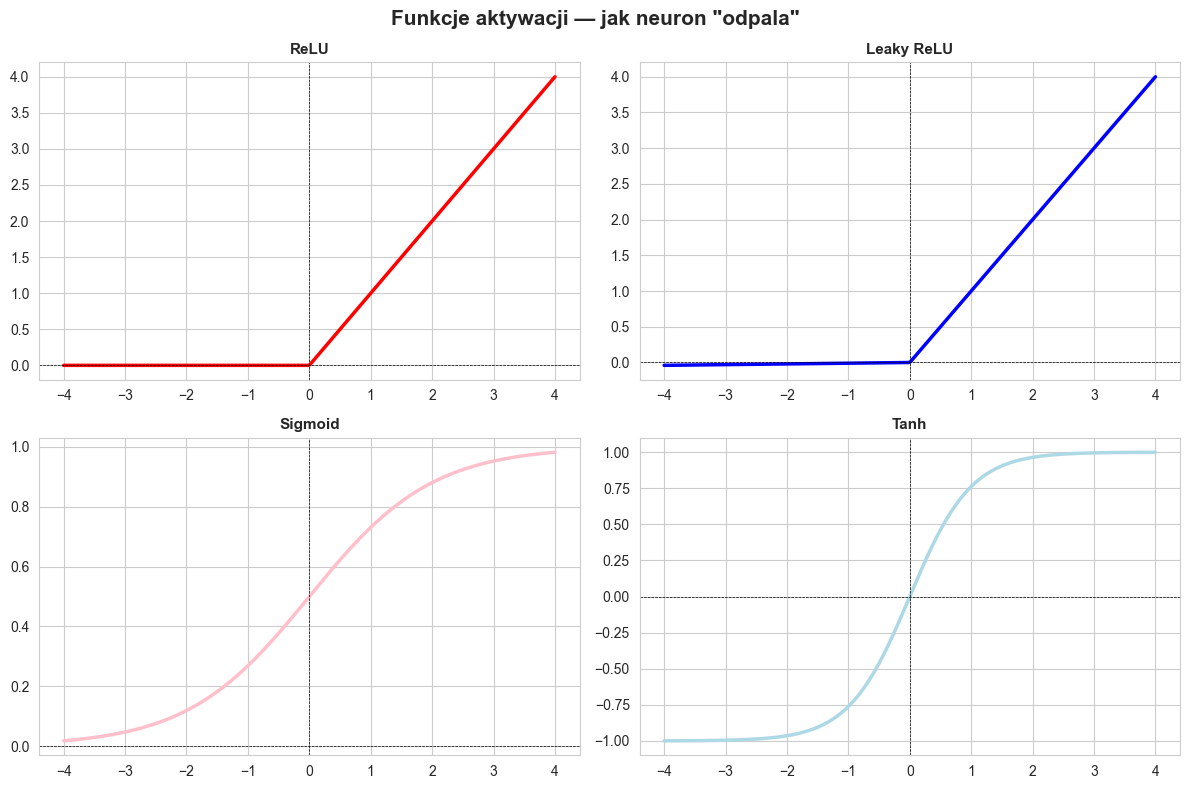

In [48]:
z = np.linspace(-4, 4, 300)

relu = np.maximum(0, z)
leaky_relu = np.where(z > 0, z, 0.01 * z)
sigmoid = 1 / (1 + np.exp(-z))
tanh_f = np.tanh(z)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Funkcje aktywacji — jak neuron "odpala"', fontsize=15, fontweight='bold')

plots = [
    (axes[0, 0], relu, 'ReLU', 'red'),
    (axes[0, 1], leaky_relu, 'Leaky ReLU', 'blue'),
    (axes[1, 0], sigmoid, 'Sigmoid', 'pink'),
    (axes[1, 1], tanh_f, 'Tanh', 'lightblue'),
]

for ax, data, title, color in plots:
    ax.plot(z, data, color=color, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')

    ax.set_title(title, fontweight='bold', fontsize=11)


plt.tight_layout()
plt.show()

---
## 2. Architektura sieci — jak wygląda całość? <a name='architektura'></a>

Neurony są ułożone w **warstwy**:
- **Warstwa wejściowa** — każdy neuron to jedna cecha danych (np. stres, wiek, sen)
- **Warstwy ukryte** — tu dzieje się "magia" — sieć wykrywa wzorce
- **Warstwa wyjściowa** — odpowiedź sieci (np. 0/1 dla klasyfikacji, liczba dla regresji)

Nasze sieci:
```
[27 wejść] → [128 neuronów] → [64 neurony] → [1 wyjście]
              warstwa ukryta 1  warstwa ukryta 2
```

---
## 3. Jak sieć się uczy? <a name='uczenie'></a>

### Krok 1: Propagacja wprzód (Forward Propagation)
Dane wchodzą przez warstwę wejściową i "płyną" do przodu przez warstwy ukryte.
Na końcu sieć daje odpowiedź — na początku zwykle **losową i złą**.

### Krok 2: Obliczenie błędu (Loss Function)
Porównujemy odpowiedź sieci z prawidłową odpowiedzią:
- **Klasyfikacja** → Binary Cross-Entropy: kara za pewność przy złej odpowiedzi
- **Regresja** → MSE: kara proporcjonalna do kwadratu błędu

### Krok 3: Propagacja wsteczna (Backpropagation)
Algorytm oblicza: *o ile zmienić każdą wagę, żeby błąd był mniejszy?*
Używa **reguły łańcuchowej** z rachunku różniczkowego.

### Krok 4: Aktualizacja wag (SGD + Momentum)
```
v = β·v + (1-β)·gradient    # momentum
w = w - lr·v                # aktualizacja
```

# Classification

## 4. Model Klasyfikacyjny — przewidywanie zdrowia psychicznego <a name='klasyfikacja'></a>

**Zbiór danych:** Digital Diet & Mental Health (Kaggle)
https://www.kaggle.com/datasets/khushikyad001/impact-of-screen-time-on-mental-health

**Cel:** Klasyfikacja binarna — czy osoba jest psychicznie zagrożona (1) czy zdrowa (0)?

**Etykieta `is_depressed = 1` jeśli spełniony przynajmniej jeden warunek:**
- mental_health_score < 0.4 (niski wynik zdrowia psychicznego)
- stress_level > 0.7 (wysoki stres, po standaryzacji)
- weekly_anxiety_score > 0.8 (wysoki wynik lęku)

> ⚠️ Dane są sztuczne (syntetyczne) — stąd bardzo dobre wyniki (MAE ~0.3, accuracy ~93%)

In [49]:
# =======================================================
# POBIERANIE DANYCH
# =======================================================
data = pd.read_csv("/neural-networks\data\digital_diet_mental_health.csv")
data = data.sample(frac=1).reset_index(drop=True)

raw = data.copy()

# Przerabianie danych gender i locational_type na (0,1) (False/True) w osobnych kolumnach by model je nie odbierał rangowo i żeby nie wpływało to na wagi
data = data.drop('user_id', axis=1)
data = pd.get_dummies(data, columns=['gender', 'location_type'])
data = data.astype(float)

# Scaling, by każda kolumna byla z skali (0-1)
data = (data - data.mean()) / data.std()

# Deciding who is and isnt healthy
data['is_depressed'] = np.where(
    (data['mental_health_score'] < 0.3) |
    (data['stress_level'] > 0.8) |
    (data['weekly_anxiety_score'] > 0.8),
    1.0, 0.0)

# TARGET
y = data['is_depressed'].values.reshape(2000, 1)
# FEATURES
X = data.drop('is_depressed', axis=1).values

rows, cols = X.shape

print(f'Klasa 0 (zdrowi):    {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'Klasa 1 (niezdrowi): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')


Klasa 0 (zdrowi):    411 (20.5%)
Klasa 1 (niezdrowi): 1589 (79.5%)


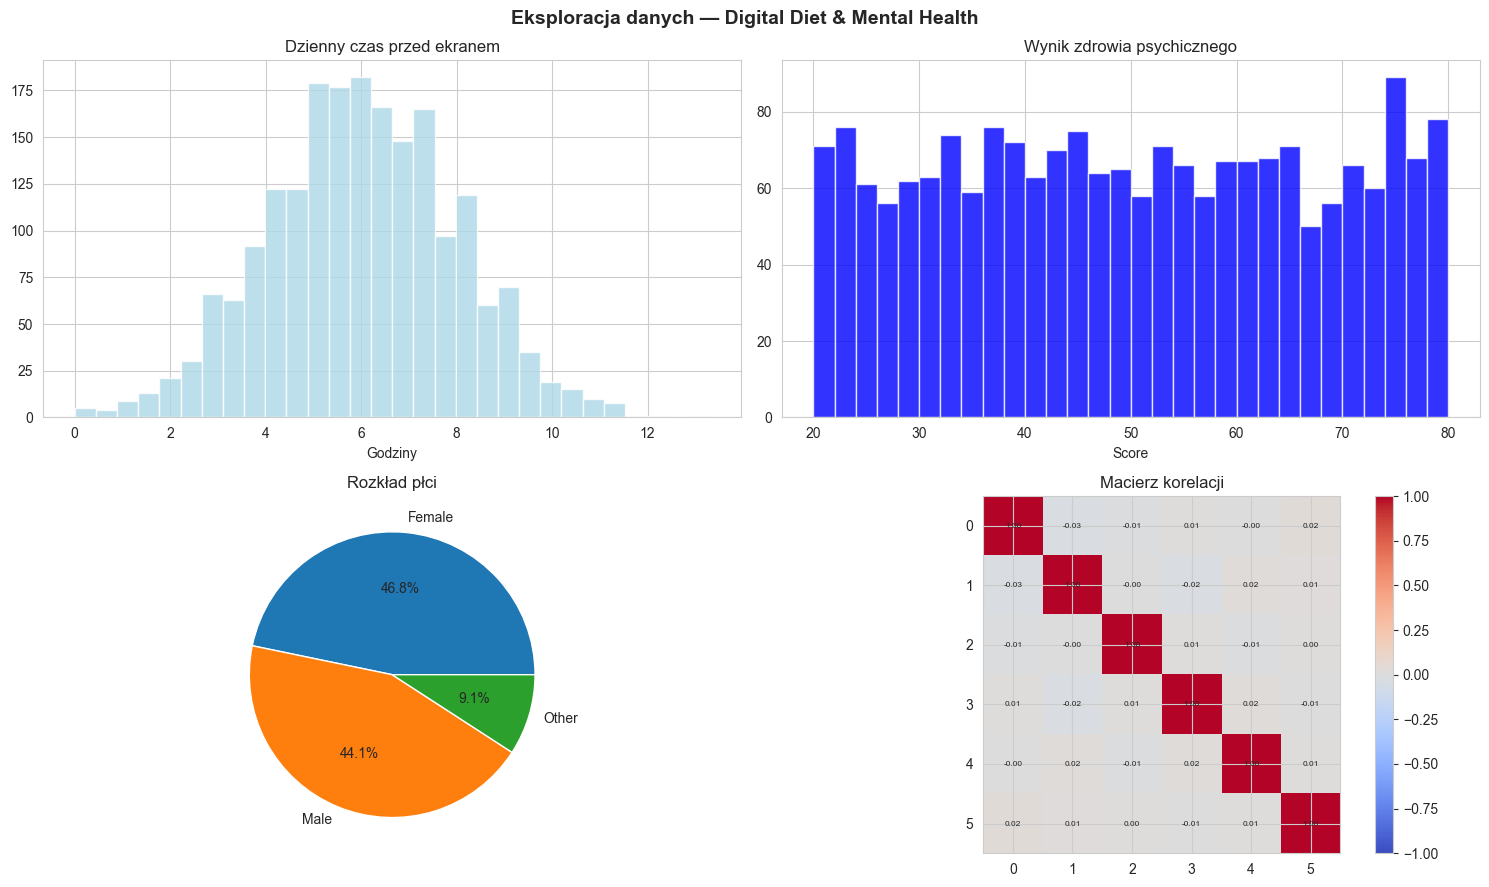

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Eksploracja danych — Digital Diet & Mental Health', fontsize=14, fontweight='bold')

axes[0,0].hist(raw['daily_screen_time_hours'], bins=30, color='lightblue', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Dzienny czas przed ekranem')
axes[0,0].set_xlabel('Godziny')

axes[0,1].hist(raw['mental_health_score'], bins=30, color='blue', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Wynik zdrowia psychicznego')
axes[0,1].set_xlabel('Score')

gender_counts = raw['gender'].value_counts()
axes[1,0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[1,0].set_title('Rozkład płci')

top_cols = ['sleep_duration_hours', 'stress_level', 'mental_health_score',
            'daily_screen_time_hours', 'physical_activity_hours_per_week',
            'weekly_anxiety_score']
corr = raw[top_cols].corr()
im = axes[1,1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
for i in range(len(top_cols)):
    for j in range(len(top_cols)):
        axes[1,1].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6)
axes[1,1].set_title('Macierz korelacji')
plt.colorbar(im, ax=axes[1,1])

plt.tight_layout()
plt.show()

In [51]:
# =======================================================
# NEURAL NETWORK - Classification
# =======================================================
class Mentally_Unwell_Prediction:
    # Initialize the model
    def __init__(self):
        self.input = cols
        self.output = 1
        self.hidden_units = 128

        # Initialize matrix of weights
        self.w1 = np.random.randn(self.input, self.hidden_units)* np.sqrt(2. / self.input)  #27*128 matrix
        self.w2 = np.random.randn(self.hidden_units, 64)* np.sqrt(2. / self.hidden_units)   #128*64 matrix
        self.w3 = np.random.randn(64, self.output)* np.sqrt(2. / 64 )                       #64*1 matrix

        # Velocity
        self.v1 = np.zeros_like(self.w1)
        self.v2 = np.zeros_like(self.w2)
        self.v3 = np.zeros_like(self.w3)

        # Biases - initialized to 0
        self.b1 = np.zeros((self.hidden_units, 1))
        self.b2 = np.zeros((64, 1))
        self.b3 = np.zeros((self.output, 1))

    # Foward move from input layer through hidden layers, multiplying neuron by weight
    def _forward_propagation(self, X):
        # Layer 1 (from input to hidden layer 1)
        self.z2 = np.dot(self.w1.T, X.T) + self.b1
        self.a2 = self._ReLU(self.z2)

        # Layer 2 (from hidden layer 1 to hidden layer 2)
        self.z3 = np.dot(self.w2.T, self.a2) + self.b2
        self.a3 = self._ReLU(self.z3)

        # Output layer (Sigmoid for binary classification)
        self.z4 = np.dot(self.w3.T, self.a3) + self.b3
        self.a4 = self._sigmoid(self.z4)

        return self.a4

    # Rectified Linear Unit
    def _ReLU(self, Z): return np.maximum(Z, 0)

    # Sigmoid
    def _sigmoid(self, z): return 1 / (1 + np.exp(-z))

    # Binary Cross Entropy (Log Loss)
    def _loss(self, predict, y):
        """
        BCE = -(1/m) * Σ [ y·log(ŷ) + (1-y)·log(1-ŷ) ]
        The lower the result, the better the model
        """
        m = y.shape[0]
        logprobs = np.multiply(np.log(predict), y) + np.multiply((1 - y), np.log(1 - predict))
        loss =- np.sum(logprobs) / m
        return loss

    def _backward_propagation(self, X, y):
        """
        Calculating the derivative of the loss function over every weight
        Chain: ∂L/∂w = ∂L/∂z · ∂z/∂w
        """
        predict = self._forward_propagation(X)
        rows = X.shape[0]

        # Output Layer (Sigmoid + BCE)
        dz4 = predict - y.T

        self.dw3 = (1 / rows) * np.dot(self.a3, dz4.T)
        self.db3 = (1 / rows) * np.sum(dz4, axis=1, keepdims=True)

        # Hidden Layer 2 (ReLU)
        dz3 = np.dot(self.w3, dz4) * self._ReLU_prime(self.z3)
        self.dw2 = (1 / rows) * np.dot(self.a2, dz3.T)
        self.db2 = (1 / rows) * np.sum(dz3, axis=1, keepdims=True)

        # Hidden Layer 1 (ReLU)
        dz2 = np.dot(self.w2, dz3) * self._ReLU_prime(self.z2)
        self.dw1 = (1 / rows) * np.dot(X.T, dz2.T)
        self.db1 = (1 / rows) * np.sum(dz2, axis=1, keepdims=True)

    def _ReLU_prime(self, z): return (z>0).astype(float)
    def _sigmoid_prime(self, z): return self._sigmoid(z) * (1 - self._sigmoid(z))

    def _update(self, learning_rate=0.01):
        beta = 0.9
        self.v1 = beta * self.v1 + (1-beta) * self.dw1
        self.w1 = self.w1 - learning_rate * self.v1
        self.b1 = self.b1 - learning_rate * self.db1

        self.v2 = beta * self.v2 + (1 - beta) * self.dw2
        self.w2 = self.w2 - learning_rate * self.v2
        self.b2 = self.b2 - learning_rate * self.db2

        self.v3 = beta * self.v3 + (1 - beta) * self.dw3
        self.w3 = self.w3 - learning_rate * self.v3
        self.b3 = self.b3 - learning_rate * self.db3

    def train(self, X_train, y_train, X_test, y_test, iteration=1000):
        learning_rate = 0.001
        batch_size = 16
        rows = X_train.shape[0]

        history = {'epoch': [], 'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

        for i in range(iteration):
            idx = np.random.permutation(rows)

            X_s, y_s = X_train[idx], y_train[idx]

            for s in range(0, rows, batch_size):
                X_b, y_b = X_s[s:s + batch_size], y_s[s:s + batch_size]

                self._backward_propagation(X_b, y_b)
                self._update(learning_rate)

            if i % 100 == 0:
                full_y_hat = self._forward_propagation(X_train)
                predictions = (full_y_hat.T > 0.5).astype(float)
                accuracy_train = np.mean(predictions == y_train)

                full_y_test = self._forward_propagation(X_test)
                predictions = (full_y_test.T > 0.5).astype(float)
                accuracy_test = np.mean(predictions == y_test)

                print(f"Iter {i} | Loss: {self._loss(full_y_hat, y):.4f} | Accuracy: {accuracy_train * 100:.2f}%")

                history['epoch'].append(i)
                history['train_loss'].append(self._loss(full_y_hat, y_train))
                history['test_loss'].append(self._loss(full_y_test, y_test))
                history['train_acc'].append(np.mean(accuracy_train))
                history['test_acc'].append(np.mean(accuracy_test))

            if i % 200 == 0:
                learning_rate *= 0.95

        return history

    def predict(self, X):
        y_hat = self._forward_propagation(X)
        y_hat = [1 if i[0] >= 0.5 else 0 for i in y_hat.T]
        return np.array(y_hat)

    def score(self, predict, y):
        predict = predict.flatten()
        y = y.flatten()
        cnt = np.sum(predict == y)
        return (cnt / len(y)) * 100

In [52]:
# =======================================================
# TRENOWANIE MODELU
# =======================================================
def train(seperator=1600):
    X_train = X[:seperator]
    X_test = X[seperator:]

    y_train = y[:seperator]
    y_test = y[seperator:]

    print("=" * 60)
    print("CLASSIFICATION MODEL TRAINING")
    print("=" * 60)

    model = Mentally_Unwell_Prediction()

    model_history = model.train(X_train, y_train, X_test, y_test)
    pre_y = model.predict(X_test)
    score = model.score(pre_y, y_test)

    print(f'=== SCORE: {score:.2f}%')

    # === Comparison of last 15 data rows
    def show_comparison(model, X_test, y_test):
        probs = model.predict(X_test)
        predictions = (probs.T > 0.5).astype(int)

        comparison = pd.DataFrame({
            'Actual Healthstatus': y_test.flatten(),
            'Predicted Health status': predictions.flatten()
        })

        print("\n=== ACTUAL VS PREDICTED ===")
        print(comparison.tail(15).to_string(index=False))
        acc = (comparison['Actual Healthstatus']==comparison['Predicted Health status']).mean()
        print(f"\nAverage Error: {acc*100:.1f}")

    show_comparison(model, X_test, y_test)

    return model, model_history, score

model, model_history, model_score = train()

CLASSIFICATION MODEL TRAINING
Iter 0 | Loss: 1114.4962 | Accuracy: 62.88%
Iter 100 | Loss: 1498.1342 | Accuracy: 90.38%
Iter 200 | Loss: 1859.3290 | Accuracy: 92.88%
Iter 300 | Loss: 2115.5454 | Accuracy: 94.69%
Iter 400 | Loss: 2386.8923 | Accuracy: 96.69%
Iter 500 | Loss: 2651.8955 | Accuracy: 97.88%
Iter 600 | Loss: 2925.6837 | Accuracy: 98.88%
Iter 700 | Loss: 3183.2213 | Accuracy: 99.56%
Iter 800 | Loss: 3427.8719 | Accuracy: 99.75%
Iter 900 | Loss: 3652.4171 | Accuracy: 99.88%
=== SCORE: 91.75%

=== ACTUAL VS PREDICTED ===
 Actual Healthstatus  Predicted Health status
                 1.0                        1
                 1.0                        1
                 1.0                        1
                 1.0                        1
                 0.0                        1
                 1.0                        0
                 1.0                        1
                 1.0                        1
                 0.0                        0
     

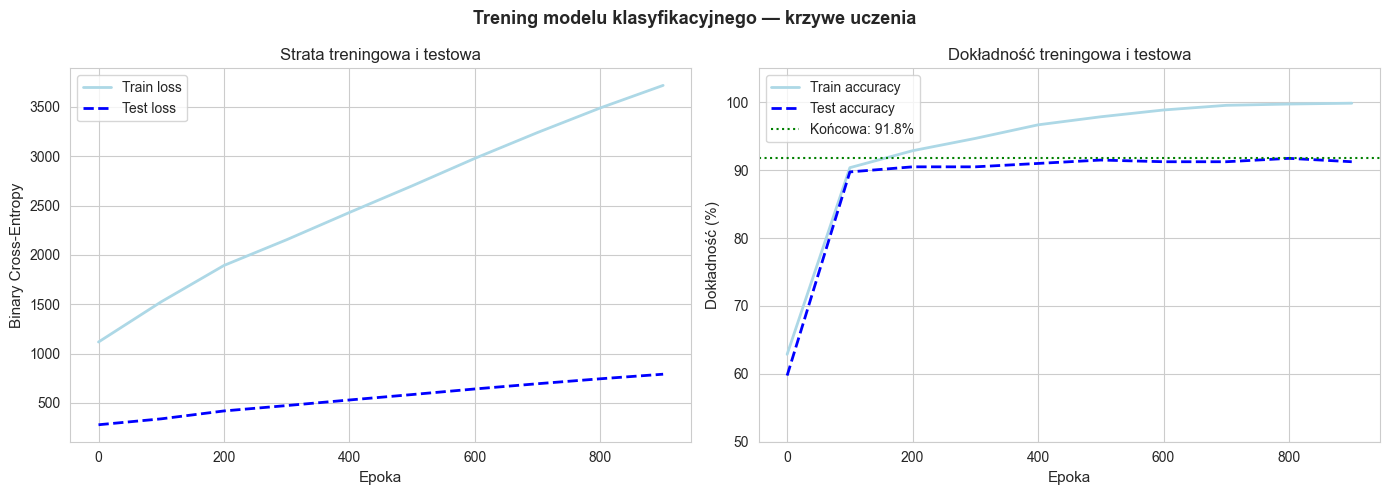

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trening modelu klasyfikacyjnego — krzywe uczenia', fontsize=13, fontweight='bold')

ep = model_history['epoch']

ax1.plot(ep, model_history['train_loss'], color='lightblue', linewidth=2, label='Train loss')
ax1.plot(ep, model_history['test_loss'],  color='blue', linewidth=2, linestyle='--', label='Test loss')
ax1.set_xlabel('Epoka', fontsize=11)
ax1.set_ylabel('Binary Cross-Entropy', fontsize=11)
ax1.set_title('Strata treningowa i testowa')
ax1.legend()


ax2.plot(ep, [a*100 for a in model_history['train_acc']], color='lightblue', linewidth=2, label='Train accuracy')
ax2.plot(ep, [a*100 for a in model_history['test_acc']],  color='blue', linewidth=2, linestyle='--', label='Test accuracy')
ax2.set_xlabel('Epoka', fontsize=11)
ax2.set_ylabel('Dokładność (%)', fontsize=11)
ax2.set_title('Dokładność treningowa i testowa')
ax2.legend()
ax2.set_ylim([50, 105])
ax2.axhline(model_score, color='green', linestyle=':', linewidth=1.5,
            label=f'Końcowa: {model_score:.1f}%')
ax2.legend()

plt.tight_layout()
plt.show()

---

# Regression

## 5. Model Regresyjny — przewidywanie długości snu <a name='regresja'></a>

**Cel:** Przewidywanie ciągłej wartości — ile godzin spi dana osoba?

**Kluczowe różnice vs klasyfikacja:**
- Warstwa wyjściowa jest **liniowa** (bez aktywacji) — wartość może być dowolna
- Funkcja straty to **MSE** (mean squared error) zamiast cross-entropy
- Metryka oceny to **MAE** (średni błąd bezwzględny) w godzinach
- Używamy **Leaky ReLU** — zapobiega "martwym neuronom" w głębszych sieciach

### Data Prep

In [54]:
# === DOWNLOADING DATASET
data = pd.read_csv("/neural-networks\data\digital_diet_mental_health.csv")
data = data.sample(frac=1).reset_index(drop=True)

data = data.drop('user_id', axis=1)

# One-Hot Encoding
# Encode text columns (gender and locational_type) into categorical an seperate 0/1 columns to avoid the neural network assigning weight based on status or hierarchy
data = pd.get_dummies(data, columns=['gender', 'location_type'])
data = data.astype(float)

# Create 'Smarter' features to improve model
data['stress_phone_interaction'] = data['stress_level'] * data['phone_usage_hours']
data['total_digital_load'] = data['phone_usage_hours'] + data['laptop_usage_hours'] + data['gaming_hours']

# used for testing prediction at the very end!
raw = data.copy()

# Min-Max Scaling
# Scaling all data so that every column is on a scale of (0, 1)
data = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0))

# === TARGET - what we want to predict
y = data['sleep_duration_hours'].values.reshape(2000, 1)
# === FEATURES - what we base our predictions off
X = data.drop(columns='sleep_duration_hours').values

rows, cols = X.shape
print(X.shape)

print(f'Zakres snu (znormalizowany): {y.min():.3f} – {y.max():.3f}')
print(f'Zakres snu (godziny): {raw["sleep_duration_hours"].min():.1f} – '
      f'{raw["sleep_duration_hours"].max():.1f} h')

(2000, 29)
Zakres snu (znormalizowany): 0.000 – 1.000
Zakres snu (godziny): 3.0 – 10.0 h


### The neural network

In [55]:
# === NEURAL NETWORK The Prologue
class Sleep_Prediction:
    """Sieć neuronowa: [29] → [128, LeakyReLU] → [64, LeakyReLU] → [1, Linear]"""

    # === Initialize the model - a function that is called on upon creating a Sleep_Prediction Class
    def __init__(self):
        self.input = cols
        self.output = 1
        self.hidden_units = 128

        # 3-Layer MLP: Input (27) -> 128 -> 64 -> Output (1)

        # Weights
        # using He Initialization to prevent the signal from dying out or exploding
        self.w1 = np.random.randn(self.input, self.hidden_units)* np.sqrt(2. / self.input)  #27*128 matrix
        self.w2 = np.random.randn(self.hidden_units, 64)* np.sqrt(2. / self.hidden_units)   #128*64 matrix
        self.w3 = np.random.randn(64, self.output)* np.sqrt(2. / 64 )                       #64*1 matrix

        # Velocity - for speed and stability, store the speed of each weight
        self.v1 = np.zeros_like(self.w1)
        self.v2 = np.zeros_like(self.w2)
        self.v3 = np.zeros_like(self.w3)

        # Biases - for flexibility
        self.b1 = np.zeros((self.hidden_units, 1))
        self.b2 = np.zeros((64, 1))
        self.b3 = np.zeros((self.output, 1))

    # === Foward move from input layer through hidden layers, multiplying neuron by weight
    def _forward_propagation(self, X):
        self.z2 = np.dot(self.w1.T, X.T) + self.b1
        self.a2 = self.ReLU(self.z2)

        self.z3 = np.dot(self.w2.T, self.a2) + self.b2
        self.a3 = self.ReLU(self.z3)

        self.z4 = np.dot(self.w3.T, self.a3) + self.b3
        self.a4 = self.z4   # liniowa

        return self.a4

    # === Rectified Linear Unit
    def ReLU(self, Z):
        # normal ReLu: return np.maximum(Z, 0)
        # leaky ReLu (to prevent dying neurons):
        return np.where(Z > 0, Z, Z * 0.01)

    # === Square Error Function
    def _loss(self, predict, y):
        m = y.shape[0]
        loss = 1/m * np.sum((predict - y.T)**2)
        return loss

    def _backward_propagation(self, X, y):
        predict = self._forward_propagation(X)
        rows = X.shape[0]

        # L2 Penalty
        lambda_param = 0.001

        dz4 = predict - y.T # Shape: (1, rows)

        self.dw3 = (1 / rows) * np.dot(self.a3, dz4.T) + (lambda_param * self.w3) # Shape: (64, 1)
        delta3 = np.dot(self.w3, dz4)
        self.db3 = (1/rows) * np.sum(dz4, axis=1, keepdims=True)
        dz3 = delta3 * self.ReLU_prime(self.z3)

        self.dw2 = (1 / rows) * np.dot(self.a2, dz3.T) + (lambda_param * self.w2)
        delta2 = np.dot(self.w2, dz3)
        self.db2 = (1 / rows) * np.sum(dz3, axis=1, keepdims=True)
        dz2 = delta2 * self.ReLU_prime(self.z2)

        self.dw1 = (1 / rows) * np.dot(X.T, dz2.T) + (lambda_param * self.w1)
        delta1 = np.dot(self.w1, dz2)
        self.db1 = (1 / rows) * np.sum(dz2, axis=1, keepdims=True)

    def ReLU_prime(self, z):
        #return (z>0).astype(float)
        return np.where(z > 0, 1, 0.01) # Leaky ReLu_Prime

    def _update(self, learning_rate=0.01):
        # beta - friction to keep velocity from growing infinitly
        beta = 0.9

        # New Velocity = (Friction * Old Velocity) + (Push from Gravity)
        self.v1 = beta * self.v1 + (1-beta) * self.dw1

        # New Position = Old Position - (Learning Rate * Velocity)
        self.w1 = self.w1 - learning_rate * self.v1

        # New Bias = Old Bias - (Learning Rate * _)
        self.b1 = self.b1 - learning_rate * self.db1

        self.v2 = beta * self.v2 + (1 - beta) * self.dw2
        self.w2 = self.w2 - learning_rate * self.v2
        self.b2 = self.b2 - learning_rate * self.db2

        self.v3 = beta * self.v3 + (1 - beta) * self.dw3
        self.w3 = self.w3 - learning_rate * self.v3
        self.b3 = self.b3 - learning_rate * self.db3

    def train(self, X_train, y_train, X_test, y_test, iteration=1000):
        learning_rate = 0.008
        batch_size = 40
        rows = X_train.shape[0]

        history = {'epoch': [], 'train_mae': [], 'test_mae': []}

        for i in range(iteration):
            idx = np.random.permutation(rows)
            X_s, y_s = X_train[idx], y_train[idx]

            for s in range(0, rows, batch_size):
                X_b, y_b = X_s[s:s + batch_size], y_s[s:s + batch_size]

                self._backward_propagation(X_b, y_b)
                self._update(learning_rate)

            if i % 100 == 0:
                full_y_hat = self._forward_propagation(X_train)
                train_mae = np.mean(np.abs(full_y_hat.T - y_train))*10

                full_y_test = self._forward_propagation(X_test)
                test_mae = np.mean(np.abs(full_y_test.T - y_test))*10

                print(f"Iter {i} | Train MAE: {train_mae:.4f} | Test MAE: {test_mae:.4f}")

                history['epoch'].append(i)
                history['train_mae'].append(train_mae)
                history['test_mae'].append(test_mae)

            if i % 100 == 0:
                learning_rate *= 0.8
        return history

    def predict(self, X):
        y_hat_scaled = self._forward_propagation(X)
        return np.maximum(0, np.array(y_hat_scaled.T)*10)

    def score(self, predict, y):
        return np.mean(np.abs(predict - y))

In [56]:
# === TRAINING THE MODEL
def train():
    X_train = X[:1600]
    X_test = X[1600:]

    y_train = y[:1600]
    y_test = y[1600:]

    clr = Sleep_Prediction()  # initialize the model

    model_history = clr.train(X_train, y_train/10, X_test, y_test/10)  # train model
    pre_y = clr.predict(X_test)  # predict
    score = clr.score(pre_y, y_test)  # get the accuracy score

    print('=== SCORE: ', score)


    def show_comparison(model, X_test, y_test):
        predictions = model.predict(X_test)

        comparison = pd.DataFrame({
            'Actual Hours': y_test.flatten().round(2),
            'Predicted Hours': predictions.flatten().round(2)
        })

        comparison['Error (Minutes)'] = (np.abs(comparison['Actual Hours'] - comparison['Predicted Hours']) * 60).round(
            0)

        print("\n=== ACTUAL VS PREDICTED ===")
        print(comparison.head(10)*10)

        print(f"\nAverage Error: {comparison['Error (Minutes)'].mean():.1f} minutes")

    show_comparison(clr, X_test, y_test)

    return clr, model_history, score, X_train, X_test, y_train, y_test, pre_y

reg, reg_history, score, X_train, X_test, y_train, y_test, pre_y = train()

Iter 0 | Train MAE: 2.0364 | Test MAE: 1.9572
Iter 100 | Train MAE: 0.5019 | Test MAE: 0.5238
Iter 200 | Train MAE: 0.3842 | Test MAE: 0.4116
Iter 300 | Train MAE: 0.3295 | Test MAE: 0.3560
Iter 400 | Train MAE: 0.2977 | Test MAE: 0.3240
Iter 500 | Train MAE: 0.2767 | Test MAE: 0.3028
Iter 600 | Train MAE: 0.2624 | Test MAE: 0.2883
Iter 700 | Train MAE: 0.2523 | Test MAE: 0.2776
Iter 800 | Train MAE: 0.2451 | Test MAE: 0.2698
Iter 900 | Train MAE: 0.2397 | Test MAE: 0.2639
=== SCORE:  0.25640566498191564

=== ACTUAL VS PREDICTED ===
   Actual Hours  Predicted Hours  Error (Minutes)
0           4.9              6.5            100.0
1           6.3              8.8            150.0
2           5.1              4.7             20.0
3           7.3              3.5            230.0
4           6.6              9.6            180.0
5           5.9              3.4            150.0
6           7.4              2.9            270.0
7           4.9              4.1             50.0
8          

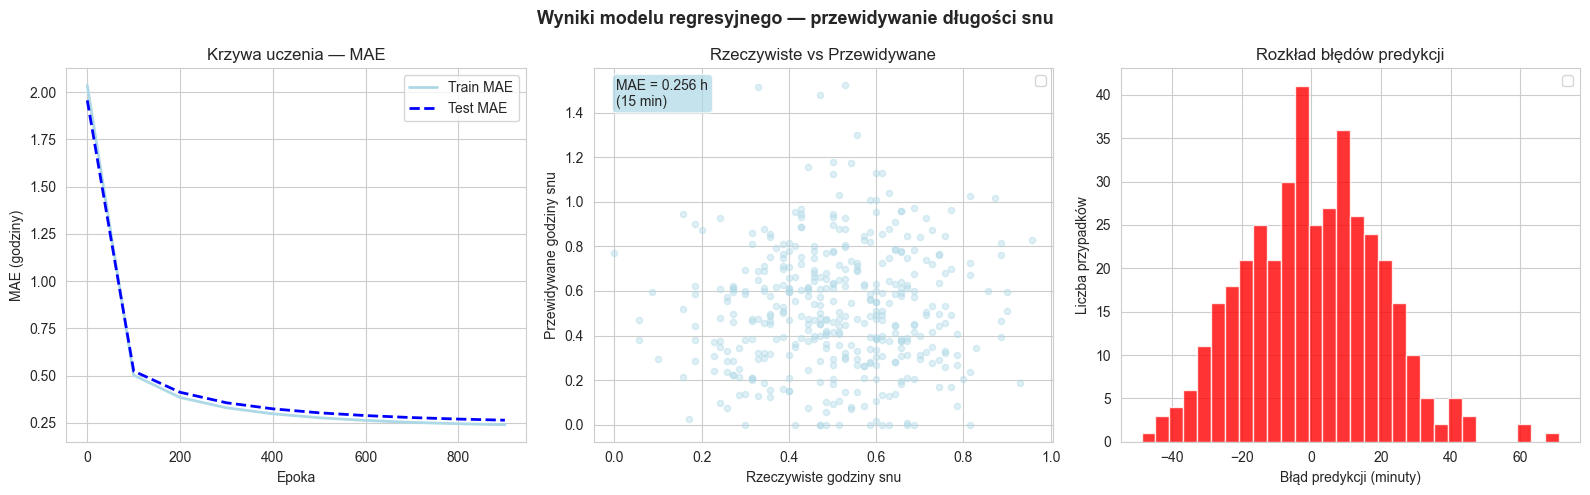

In [57]:
y_test_h  = y_test.flatten()
y_pred_h  = pre_y.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Wyniki modelu regresyjnego — przewidywanie długości snu', fontsize=13, fontweight='bold')

axes[0].plot(reg_history['epoch'], reg_history['train_mae'], color='lightblue', linewidth=2, label='Train MAE')
axes[0].plot(reg_history['epoch'], reg_history['test_mae'],  color='blue', linewidth=2, linestyle='--', label='Test MAE')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('MAE (godziny)')
axes[0].set_title('Krzywa uczenia — MAE')
axes[0].legend()

axes[1].scatter(y_test_h, y_pred_h, alpha=0.4, color='lightblue', s=20)
axes[1].set_xlabel('Rzeczywiste godziny snu')
axes[1].set_ylabel('Przewidywane godziny snu')
axes[1].set_title('Rzeczywiste vs Przewidywane')
axes[1].legend()
axes[1].text(0.05, 0.90, f'MAE = {score:.3f} h\n({score*60:.0f} min)',
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

errors_min = (y_pred_h - y_test_h) * 60
axes[2].hist(errors_min, bins=30, color='red', alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Błąd predykcji (minuty)')
axes[2].set_ylabel('Liczba przypadków')
axes[2].set_title('Rozkład błędów predykcji')
axes[2].legend()

plt.tight_layout()
plt.show()

# Wnioski

---
## 6. Wnioski <a name='wnioski'></a>

Sprawdzamy jak nasza własna implementacja wypada na tle gotowych modeli ze sklearn.
Testujemy cztery algorytmy dla obu problemów.